# 冠状动脉斑块进展预测 — 数据预处理

**任务**:基于 CTA + 临床/实验室数据预测目标病变是否进展(`target_lesion_positive`)。

**本 Notebook 内容**:
1. 数据加载与基本信息
2. 目标变量分布
3. 删除常数列 / 全空列 / 数据泄漏列
4. 缺失值分析与处理
5. 分类变量编码(有序 + One-Hot)
6. 异常值检测(IQR 标记)
7. 特征工程:基线 vs 随访的 Δ(差值)/比值特征
8. 特征集划分(baseline-only / baseline+followup / 全特征)
9. **按患者(accession_id)分组**的训练/验证/测试集划分
10. 数值特征标准化(仅 fit on train)
11. 持久化为 `.parquet` / `.npz`,供下游建模使用

In [1]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 200)
sns.set_style('whitegrid')
RNG = 42

DATA_PATH = 'final_paired_analysis_ml.csv'
OUT_DIR = 'processed'
os.makedirs(OUT_DIR, exist_ok=True)
print('Output directory:', OUT_DIR)

Output directory: processed


## 1. 加载数据 & 基本概览

In [2]:
df = pd.read_csv(DATA_PATH)
print(f'数据形状: {df.shape}')
print(f'唯一患者数 (accession_id): {df["accession_id"].nunique()}')
print(f'每位患者的病变数分布:')
print(df.groupby('accession_id').size().value_counts().sort_index())
df.head(3)

数据形状: (2208, 113)
唯一患者数 (accession_id): 1314
每位患者的病变数分布:
1    650
2    462
3    177
4     22
5      3
Name: count, dtype: int64


,accession_id,artery_vessel,lesion_segment,contact_segment,current_intervention_flag,prior_revascularization_flag,target_lesion_positive,sex,age_years,history_hypertension,history_diabetes,history_smoking,history_pci,history_cabg,cta_admission_number,baseline_ctnt,baseline_nt_pro_bnp,baseline_creatinine,baseline_uric_acid,baseline_ck,baseline_ck_mb,baseline_crp,baseline_albumin,baseline_alt,baseline_mcv,baseline_wbc,baseline_neutrophil_pct,baseline_lymphocyte_pct,baseline_platelet_count,baseline_pdw,baseline_total_cholesterol,baseline_ldl,baseline_hdl_cholesterol,baseline_triglycerides,baseline_lipoprotein_a,baseline_hba1c,baseline_lv_end_diastolic_diameter,baseline_lv_end_systolic_diameter,baseline_lvef,postop_ctnt,postop_nt_pro_bnp,postop_ck,postop_ck_mb,followup_ctnt,followup_nt_pro_bnp,followup_creatinine,followup_uric_acid,followup_ck,followup_ck_mb,followup_crp,followup_albumin,followup_alt,followup_mcv,followup_wbc,followup_neutrophil_pct,followup_lymphocyte_pct,followup_platelet_count,followup_pdw,followup_total_cholesterol,followup_ldl,followup_hdl_cholesterol,followup_triglycerides,followup_lipoprotein_a,followup_hba1c,followup_lv_end_diastolic_diameter,followup_lv_end_systolic_diameter,followup_lvef,lesion_stenosis_grade,plaque_type,stent_present,myocardial_bridge_level,myocardial_bridge_depth_mm,lesion_range_mm,stenosis_percent,remodeling_index,eccentricity_index,minimum_luminal_area_mm3,maximum_diameter_stenosis_percent,maximum_area_stenosis_percent,calcified_mean_hu,calcified_volume_mm3,calcified_volume_ratio,calcified_plaque_burden,non_calcified_mean_hu,non_calcified_volume_mm3,non_calcified_volume_ratio,non_calcified_plaque_burden,low_attenuation_mean_hu,low_attenuation_volume_mm3,low_attenuation_volume_ratio,low_attenuation_plaque_burden,fibrous_fatty_mean_hu,fibrous_fatty_volume_mm3,fibrous_fatty_volume_ratio,fibrous_fatty_plaque_burden,fibrotic_mean_hu,fibrotic_volume_mm3,fibrotic_volume_ratio,fibrotic_plaque_burden,whole_lesion_volume_mm3,whole_lesion_plaque_burden,lumen_volume_mm3,vessel_volume_mm3,positive_remodeling_flag,low_attenuation_plaque_flag,napkin_ring_sign_flag,spotty_calcification_flag,max_hu,min_hu,mean_hu,std_hu,contact_volume_mm3,ffrct_value
0,ZS0025103467,LCX,LCX-Proximal,LCX-Proximal,0,0,0,1,76,1.0,1,0,1,0,542468,0.015,340.0,82.0,570.0,69.0,11.3,0.88,37.6,18.6,91.0,7.43,60.4,26.1,164.0,8.4,3.69,1.919,0.63,2.51,5.0,6.4,45.0,30.0,60.0,0.069,347.0,88.0,16.0,0.325,1332.0,84.0,445.0,117.0,21.0,1.27,38.9,12.4,90.2,7.16,74.4,16.1,140.0,7.9,3.63,1.809,0.83,2.18,10.6,6.3,49.0,30.0,64.0,Mild,Mixed,0,NaN,0,10.2,0.37,1.831854,0.999998,0.491233,0.803510,0.959466,590,11.171686,0.400685,0.011934,179,16.709788,0.599315,0.017850,21,0.095484,0.003425,0.000102,90,4.965194,0.178082,0.005304,218,11.649109,0.417808,0.012444,27.881474,0.029784,68.175933,936.130038,0,0,0,0,-30,-188,-85.31,34.76,160.80,0.88
1,ZS0025103467,RCA,RCA-Middle,RCA-Middle,0,0,0,1,76,1.0,1,0,1,0,542468,0.015,340.0,82.0,570.0,69.0,11.3,0.88,37.6,18.6,91.0,7.43,60.4,26.1,164.0,8.4,3.69,1.919,0.63,2.51,5.0,6.4,45.0,30.0,60.0,0.069,347.0,88.0,16.0,0.325,1332.0,84.0,445.0,117.0,21.0,1.27,38.9,12.4,90.2,7.16,74.4,16.1,140.0,7.9,3.63,1.809,0.83,2.18,10.6,6.3,49.0,30.0,64.0,Moderate,Mixed,0,NaN,0,15.9,0.52,1.362709,0.817131,3.359748,0.503452,0.746051,625,52.516475,0.425039,0.024621,187,71.040468,0.574961,0.033305,4,1.527752,0.012365,0.000716,91,15.754943,0.127512,0.007386,221,53.757773,0.435085,0.025203,123.556943,0.057926,120.119501,2133.028246,0,0,0,0,-30,-190,-94.90,41.17,534.33,0.90
2,ZS0025294556,LAD,LAD-Middle,LAD-Proximal,0,0,0,1,65,1.0,0,1,0,0,1154515,0.005,57.3,70.0,394.0,45.0,14.6,2.01,44.9,45.2,94.5,7.16,63.1,24.7,172.0,18.2,3.07,0.852,1.75,1.03,22.7,5.3,51.0,30.0,72.0,0.091,31.4,124.0,24.0,0.007,82.1,68.0,375.0,62.0,18.7,2.80,45.2,28.0,92.3,7.47,66.6,21.7,217.0,14.7,3.16,0.899,1.57,1.52,35.2,5.5,51.0,33.0,64.0,Mild,Mixed,0,NaN,0,23.1,0.36,1.413744,0.999997,5.367708,0.283460,0.542980,535,15.355642,0.143822,0.012937,150,91.412446,0.85617

In [3]:
df.info(verbose=False, show_counts=True)

<class 'pandas.DataFrame'>
RangeIndex: 2208 entries, 0 to 2207
Columns: 113 entries, accession_id to ffrct_value
dtypes: float64(84), int64(23), str(6)
memory usage: 2.0 MB


## 2. 目标变量
`target_lesion_positive == 1` 表示该病变在随访期间进展 / 出现目标病变事件。

类别分布:
target_lesion_positive
0    1868
1     340
Name: count, dtype: int64
阳性率: 15.399%  (类别不平衡,建模需用 class_weight 或重采样)


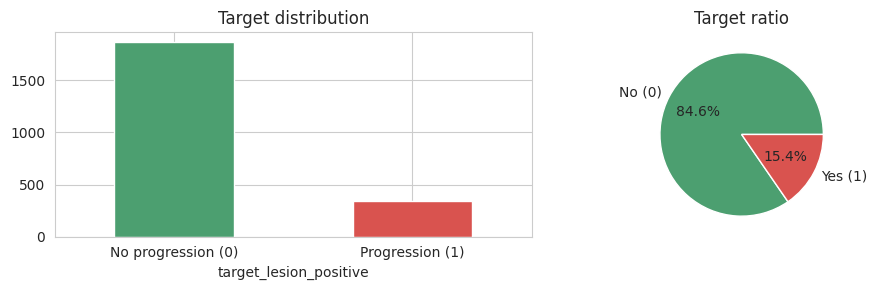

In [4]:
TARGET = 'target_lesion_positive'
y_counts = df[TARGET].value_counts()
print('类别分布:')
print(y_counts)
print(f'阳性率: {df[TARGET].mean():.3%}  (类别不平衡,建模需用 class_weight 或重采样)')

fig, ax = plt.subplots(1, 2, figsize=(10, 3))
y_counts.plot(kind='bar', ax=ax[0], color=['#4C9F70', '#D9534F'])
ax[0].set_title('Target distribution')
ax[0].set_xticklabels(['No progression (0)', 'Progression (1)'], rotation=0)
ax[1].pie(y_counts.values, labels=['No (0)', 'Yes (1)'], autopct='%.1f%%', colors=['#4C9F70', '#D9534F'])
ax[1].set_title('Target ratio')
plt.tight_layout(); plt.show()

## 3. 删除常数列 / 全空列 / ID 类列
下列列对建模无信息或会引入泄漏:
* `myocardial_bridge_level` — 全空
* `current_intervention_flag` / `prior_revascularization_flag` / `stent_present` — 全为 0(数据已经过筛选)
* `cta_admission_number` — 行政编号,会泄漏患者身份
* `accession_id` — 暂时保留用于分组划分,建模前再删

In [5]:
constant_cols = [c for c in df.columns if df[c].nunique(dropna=False) <= 1]
print('常数 / 全空列 ->', constant_cols)
drop_cols = constant_cols + ['cta_admission_number']
df = df.drop(columns=[c for c in drop_cols if c in df.columns])
print('删除后形状:', df.shape)

常数 / 全空列 -> ['current_intervention_flag', 'prior_revascularization_flag', 'stent_present', 'myocardial_bridge_level', 'myocardial_bridge_depth_mm']
删除后形状: (2208, 107)


## 4. 缺失值分析

有缺失的列数: 53


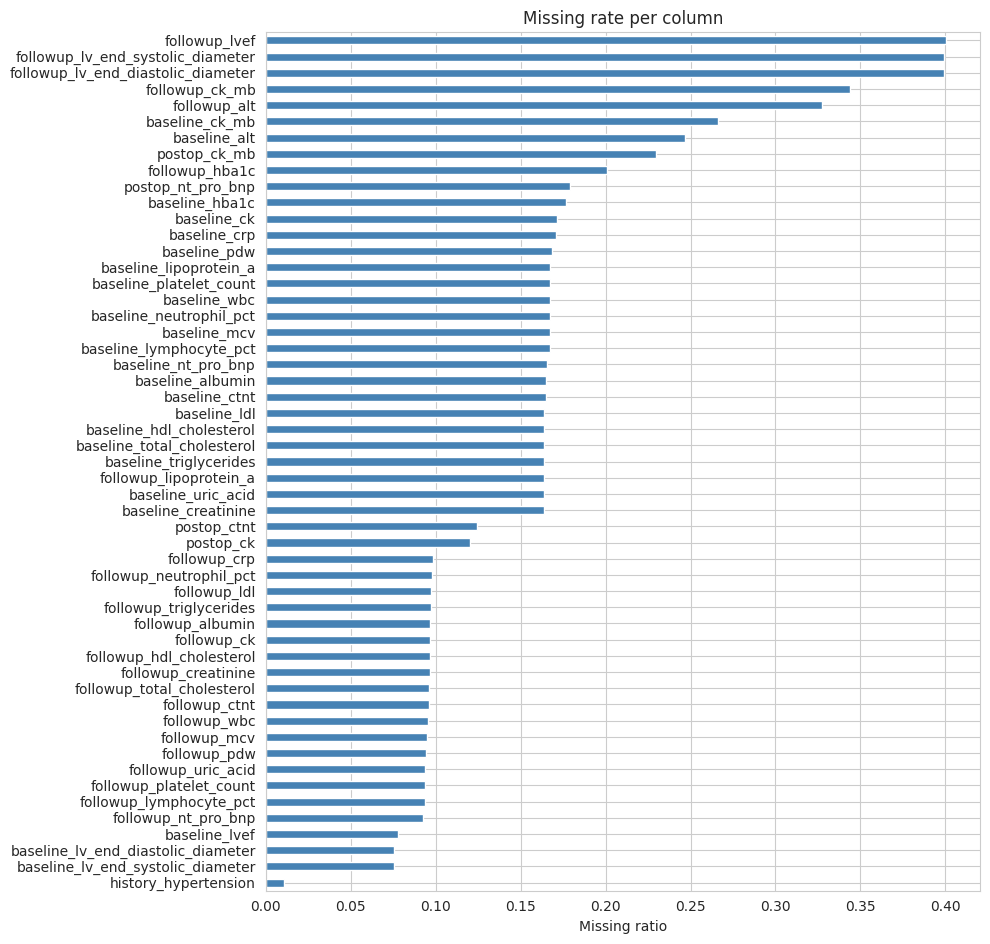

followup_lvef                         0.400362
followup_lv_end_systolic_diameter     0.399457
followup_lv_end_diastolic_diameter    0.399004
followup_ck_mb                        0.343750
followup_alt                          0.327446
baseline_ck_mb                        0.266304
baseline_alt                          0.246830
postop_ck_mb                          0.229620
followup_hba1c                        0.200634
postop_nt_pro_bnp                     0.178895
baseline_hba1c                        0.176630
baseline_ck                           0.171649
baseline_crp                          0.170743
baseline_pdw                          0.168478
baseline_lipoprotein_a                0.167572
baseline_platelet_count               0.167120
baseline_wbc                          0.167120
baseline_neutrophil_pct               0.167120
baseline_mcv                          0.167120
baseline_lymphocyte_pct               0.167120
dtype: float64

In [6]:
miss = df.isna().mean().sort_values(ascending=False)
miss = miss[miss > 0]
print(f'有缺失的列数: {len(miss)}')
fig, ax = plt.subplots(figsize=(10, max(4, len(miss)*0.18)))
miss.plot(kind='barh', ax=ax, color='steelblue')
ax.invert_yaxis()
ax.set_xlabel('Missing ratio')
ax.set_title('Missing rate per column')
plt.tight_layout(); plt.show()
miss.head(20)

In [7]:
HIGH_MISS_THRESHOLD = 0.50
high_miss_cols = miss[miss > HIGH_MISS_THRESHOLD].index.tolist()
print(f'缺失率 > {HIGH_MISS_THRESHOLD:.0%} 的列(候选删除):', high_miss_cols)

缺失率 > 50% 的列(候选删除): []


## 5. 列分组与分类变量编码

In [8]:
ID_COLS = ['accession_id']
TARGET_COL = TARGET

ORDINAL_MAP = {
    'lesion_stenosis_grade': {'Minimal': 0, 'Mild': 1, 'Moderate': 2, 'Severe': 3}
}
ONEHOT_COLS = ['artery_vessel', 'lesion_segment', 'contact_segment', 'plaque_type']

for col, mp in ORDINAL_MAP.items():
    df[col] = df[col].map(mp)
    print(f'{col} 映射后取值: {sorted(df[col].dropna().unique())}')

df = pd.get_dummies(df, columns=ONEHOT_COLS, prefix=ONEHOT_COLS, drop_first=False, dtype='int8')
print('One-Hot 后形状:', df.shape)

lesion_stenosis_grade 映射后取值: [np.int64(0), np.int64(1), np.int64(2), np.int64(3)]
One-Hot 后形状: (2208, 121)


## 6. 特征工程:Δ(随访 - 基线)与比值
对常见随访/基线配对的实验室与超声指标计算差值与百分比变化,作为补充特征。

In [9]:
baseline_cols = [c for c in df.columns if c.startswith('baseline_')]
paired = []
for bc in baseline_cols:
    fc = bc.replace('baseline_', 'followup_')
    if fc in df.columns:
        paired.append((bc, fc))
print(f'共找到 {len(paired)} 对 baseline/followup 数值特征')

for bc, fc in paired:
    base, fu = df[bc], df[fc]
    df[bc.replace('baseline_', 'delta_')] = fu - base
    safe_base = base.replace(0, np.nan)
    df[bc.replace('baseline_', 'pct_change_')] = (fu - base) / safe_base
print('增加特征后形状:', df.shape)

共找到 24 对 baseline/followup 数值特征
增加特征后形状: (2208, 169)


## 7. 异常值检测(IQR 标记,不删行)
对显著超出 1.5×IQR 的样本计数,后续建模可选用稳健模型(树模型对异常值不敏感)。

In [10]:
num_cols_for_iqr = df.select_dtypes(include=[np.number]).columns.difference([TARGET_COL])
outlier_summary = {}
for c in num_cols_for_iqr:
    s = df[c].dropna()
    if s.nunique() < 5:  # 跳过 0/1 类列
        continue
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    if iqr == 0:
        continue
    lo, hi = q1 - 1.5*iqr, q3 + 1.5*iqr
    n_out = ((s < lo) | (s > hi)).sum()
    if n_out > 0:
        outlier_summary[c] = n_out
outlier_df = pd.Series(outlier_summary).sort_values(ascending=False)
print('异常值最多的 15 列:')
print(outlier_df.head(15))

异常值最多的 15 列:
delta_nt_pro_bnp        358
calcified_mean_hu       339
eccentricity_index      327
delta_lipoprotein_a     274
delta_ctnt              271
pct_change_crp          258
postop_ctnt             219
baseline_nt_pro_bnp     217
postop_nt_pro_bnp       216
min_hu                  214
followup_ctnt           206
followup_nt_pro_bnp     206
delta_crp               204
calcified_volume_mm3    201
delta_ck                196
dtype: int64


## 8. 特征集划分
为下游建模提供 3 套特征,按需选择以避免/允许使用随访期信息:

| 特征集 | 包含 | 说明 |
|--------|------|------|
| **A. baseline-only** | 人口学 + 基线实验室 + 病变/斑块影像 | **推荐**,无数据泄漏风险 |
| **B. baseline + delta** | A + Δ/百分比变化 | 若随访指标在“判定进展”之前测得可使用 |
| **C. all** | A + 全部 followup_ + delta | 仅做对照/上限分析 |

In [11]:
DEMO_COLS = ['sex', 'age_years', 'history_hypertension', 'history_diabetes',
             'history_smoking', 'history_pci', 'history_cabg']
BASELINE_LAB_COLS = [c for c in df.columns if c.startswith('baseline_')]
POSTOP_COLS      = [c for c in df.columns if c.startswith('postop_')]
FOLLOWUP_COLS    = [c for c in df.columns if c.startswith('followup_')]
DELTA_COLS       = [c for c in df.columns if c.startswith('delta_') or c.startswith('pct_change_')]

PLAQUE_IMG_COLS = [
    'lesion_stenosis_grade', 'myocardial_bridge_depth_mm', 'lesion_range_mm',
    'stenosis_percent', 'remodeling_index', 'eccentricity_index',
    'minimum_luminal_area_mm3', 'maximum_diameter_stenosis_percent',
    'maximum_area_stenosis_percent',
    'calcified_mean_hu', 'calcified_volume_mm3', 'calcified_volume_ratio', 'calcified_plaque_burden',
    'non_calcified_mean_hu', 'non_calcified_volume_mm3', 'non_calcified_volume_ratio', 'non_calcified_plaque_burden',
    'low_attenuation_mean_hu', 'low_attenuation_volume_mm3', 'low_attenuation_volume_ratio', 'low_attenuation_plaque_burden',
    'fibrous_fatty_mean_hu', 'fibrous_fatty_volume_mm3', 'fibrous_fatty_volume_ratio', 'fibrous_fatty_plaque_burden',
    'fibrotic_mean_hu', 'fibrotic_volume_mm3', 'fibrotic_volume_ratio', 'fibrotic_plaque_burden',
    'whole_lesion_volume_mm3', 'whole_lesion_plaque_burden', 'lumen_volume_mm3', 'vessel_volume_mm3',
    'positive_remodeling_flag', 'low_attenuation_plaque_flag', 'napkin_ring_sign_flag', 'spotty_calcification_flag',
    'max_hu', 'min_hu', 'mean_hu', 'std_hu', 'contact_volume_mm3', 'ffrct_value'
]
DUMMY_COLS = [c for c in df.columns if c.startswith(('artery_vessel_','lesion_segment_','contact_segment_','plaque_type_'))]

FEATURES_BASELINE = (DEMO_COLS + BASELINE_LAB_COLS + PLAQUE_IMG_COLS + DUMMY_COLS)
FEATURES_BASELINE = [c for c in FEATURES_BASELINE if c in df.columns]
FEATURES_DELTA    = FEATURES_BASELINE + DELTA_COLS
FEATURES_ALL      = FEATURES_BASELINE + DELTA_COLS + FOLLOWUP_COLS + POSTOP_COLS

print(f'A. baseline-only      特征数: {len(FEATURES_BASELINE)}')
print(f'B. baseline + delta   特征数: {len(FEATURES_DELTA)}')
print(f'C. all (含 followup)  特征数: {len(FEATURES_ALL)}')

A. baseline-only      特征数: 91
B. baseline + delta   特征数: 139
C. all (含 followup)  特征数: 167


## 9. 按患者分组的 Train/Val/Test 划分
**关键**:同一 `accession_id` 的多条病变记录必须落在同一拆分中,避免信息泄漏到验证/测试集。

In [12]:
groups = df['accession_id'].values
y = df[TARGET_COL].values

gss1 = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=RNG)
trainval_idx, test_idx = next(gss1.split(df, y, groups))

gss2 = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=RNG)
tv_groups = groups[trainval_idx]
tr_rel, val_rel = next(gss2.split(df.iloc[trainval_idx], y[trainval_idx], tv_groups))
train_idx = trainval_idx[tr_rel]
val_idx   = trainval_idx[val_rel]

for name, idx in [('Train', train_idx), ('Val', val_idx), ('Test', test_idx)]:
    n = len(idx); ng = df.iloc[idx]['accession_id'].nunique()
    pos = y[idx].mean()
    print(f'{name:5s}: n={n:5d}  patients={ng:5d}  positive_rate={pos:.3%}')

assert set(df.iloc[train_idx]['accession_id']).isdisjoint(set(df.iloc[val_idx]['accession_id']))
assert set(df.iloc[train_idx]['accession_id']).isdisjoint(set(df.iloc[test_idx]['accession_id']))
assert set(df.iloc[val_idx]['accession_id']).isdisjoint(set(df.iloc[test_idx]['accession_id']))
print('\n✓ 三套数据的患者集合互不重叠')

Train: n= 1395  patients=  840  positive_rate=16.057%
Val  : n=  364  patients=  211  positive_rate=13.462%
Test : n=  449  patients=  263  positive_rate=14.922%

✓ 三套数据的患者集合互不重叠


## 10. 缺失值填补 + 标准化(只在 Train 上 fit)

In [13]:
def build_xy(feature_cols):
    X = df[feature_cols].copy()
    return X

def fit_transform_split(feature_cols, scale=True):
    X = build_xy(feature_cols)
    X_tr, X_val, X_te = X.iloc[train_idx].copy(), X.iloc[val_idx].copy(), X.iloc[test_idx].copy()
    y_tr, y_val, y_te = y[train_idx], y[val_idx], y[test_idx]

    imputer = SimpleImputer(strategy='median')
    X_tr_i  = pd.DataFrame(imputer.fit_transform(X_tr),  columns=feature_cols, index=X_tr.index)
    X_val_i = pd.DataFrame(imputer.transform(X_val),     columns=feature_cols, index=X_val.index)
    X_te_i  = pd.DataFrame(imputer.transform(X_te),      columns=feature_cols, index=X_te.index)

    binary_like = [c for c in feature_cols if X_tr_i[c].nunique() <= 2]
    cont_cols   = [c for c in feature_cols if c not in binary_like]

    if scale and cont_cols:
        scaler = StandardScaler()
        X_tr_i[cont_cols]  = scaler.fit_transform(X_tr_i[cont_cols])
        X_val_i[cont_cols] = scaler.transform(X_val_i[cont_cols])
        X_te_i[cont_cols]  = scaler.transform(X_te_i[cont_cols])
    else:
        scaler = None

    return dict(X_train=X_tr_i, X_val=X_val_i, X_test=X_te_i,
                y_train=y_tr,   y_val=y_val,   y_test=y_te,
                imputer=imputer, scaler=scaler, feature_cols=feature_cols)

data_A = fit_transform_split(FEATURES_BASELINE, scale=True)
data_B = fit_transform_split(FEATURES_DELTA,    scale=True)
data_C = fit_transform_split(FEATURES_ALL,      scale=True)
print('已生成 3 套预处理数据 (A/B/C),每套含 X_train/X_val/X_test 与 y_*')
print('A 形状:', data_A['X_train'].shape, data_A['X_val'].shape, data_A['X_test'].shape)

已生成 3 套预处理数据 (A/B/C),每套含 X_train/X_val/X_test 与 y_*
A 形状: (1395, 91) (364, 91) (449, 91)


### 类别权重 / 重采样建议
训练集阳性率 ≈ 15%,建议:
* 树模型(XGBoost/LightGBM/RandomForest):`scale_pos_weight = neg/pos` 或 `class_weight='balanced'`
* 逻辑回归 / 线性模型:`class_weight='balanced'`
* 或在训练集上使用 `imblearn` 的 SMOTE(注意只在 train 上做)

In [14]:
neg = (data_A['y_train'] == 0).sum()
pos = (data_A['y_train'] == 1).sum()
print(f'Train  neg={neg}  pos={pos}  scale_pos_weight = neg/pos = {neg/pos:.3f}')

Train  neg=1171  pos=224  scale_pos_weight = neg/pos = 5.228


## 11. 持久化预处理结果
保存到 `processed/`,后续建模 Notebook 直接 `np.load` / `pd.read_parquet` 即可。

In [15]:
import joblib

for name, data in [('A_baseline', data_A), ('B_baseline_delta', data_B), ('C_all', data_C)]:
    sub = os.path.join(OUT_DIR, name)
    os.makedirs(sub, exist_ok=True)
    data['X_train'].to_parquet(os.path.join(sub, 'X_train.parquet'))
    data['X_val'].to_parquet(os.path.join(sub, 'X_val.parquet'))
    data['X_test'].to_parquet(os.path.join(sub, 'X_test.parquet'))
    np.save(os.path.join(sub, 'y_train.npy'), data['y_train'])
    np.save(os.path.join(sub, 'y_val.npy'),   data['y_val'])
    np.save(os.path.join(sub, 'y_test.npy'),  data['y_test'])
    joblib.dump({'imputer': data['imputer'], 'scaler': data['scaler'],
                 'feature_cols': data['feature_cols']},
                os.path.join(sub, 'preprocessor.joblib'))
    print(f'✓ saved {sub}')

split_meta = pd.DataFrame({
    'row_index': np.concatenate([train_idx, val_idx, test_idx]),
    'split':     ['train']*len(train_idx) + ['val']*len(val_idx) + ['test']*len(test_idx),
    'accession_id': np.concatenate([df.iloc[train_idx]['accession_id'].values,
                                    df.iloc[val_idx]['accession_id'].values,
                                    df.iloc[test_idx]['accession_id'].values])
})
split_meta.to_csv(os.path.join(OUT_DIR, 'split_meta.csv'), index=False)
print('\nDone. 下一步可在 02_modeling.ipynb 中加载 processed/ 进行建模。')

✓ saved processed/A_baseline


✓ saved processed/B_baseline_delta
✓ saved processed/C_all

Done. 下一步可在 02_modeling.ipynb 中加载 processed/ 进行建模。
